# 02 – Baseline CNN (Trained from Scratch)
**Project:** AI Football Event Classifier (CNN) — Yannick Maas

This notebook builds a **simple custom CNN** as a quick baseline before moving to transfer learning.  
It predicts both the **event** label and the **view** label simultaneously (multi-task).

Run `01_data_preparation.ipynb` first so that `outputs/manifest.csv` exists.

In [7]:
import os, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm  # Add this import at the top


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
OUTPUT_DIR    = Path('outputs')
MANIFEST_PATH = OUTPUT_DIR / 'manifest.csv'
IMG_SIZE      = (128, 128)
BATCH_SIZE    = 32
NUM_EPOCHS    = 5
LR            = 1e-3

In [9]:
df = pd.read_csv(MANIFEST_PATH)
NUM_EVENT_CLASSES = df['event_idx'].nunique()
NUM_VIEW_CLASSES  = df['view_idx'].nunique()
print(f'Total images : {len(df):,}  |  Event classes: {NUM_EVENT_CLASSES}  |  View classes: {NUM_VIEW_CLASSES}')

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Total images : 2,100  |  Event classes: 2  |  View classes: 14
Train samples: 1470
Val samples: 315
Test samples: 315


In [10]:
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class FootballDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')
        except Exception as e:
            print(f"Error loading image: {row['path']} | {e}")
            img = Image.new('RGB', (128, 128))
        if self.transform:
            img = self.transform(img)
        return img, int(row['event_idx']), int(row['view_idx'])

train_loader = DataLoader(FootballDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(FootballDataset(val_df,   val_transform),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(FootballDataset(test_df,  val_transform),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('DataLoaders ready')

DataLoaders ready


In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_event_classes, num_view_classes):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(4),
        )
        self.flatten    = nn.Flatten()
        self.dropout    = nn.Dropout(0.4)
        fc_in = 256 * 4 * 4
        self.event_head = nn.Linear(fc_in, num_event_classes)
        self.view_head  = nn.Linear(fc_in, num_view_classes)

    def forward(self, x):
        x = self.dropout(self.flatten(self.backbone(x)))
        return self.event_head(x), self.view_head(x)

model = SimpleCNN(NUM_EVENT_CLASSES, NUM_VIEW_CLASSES).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 454,928


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'val_event_acc': [], 'val_view_acc': []}


def run_epoch(loader, training=True):
    phase = 'train' if training else 'validation'
    model.train() if training else model.eval()
    total_loss = event_correct = view_correct = total = 0
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for batch_idx, (imgs, ev, vw) in enumerate(tqdm(loader, desc=f"{phase.title()} Batches"), start=1):
            imgs, ev, vw = imgs.to(DEVICE), ev.to(DEVICE), vw.to(DEVICE)
            e_out, v_out = model(imgs)
            loss = criterion(e_out, ev) + criterion(v_out, vw)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            total_loss    += loss.item() * len(imgs)
            event_correct += (e_out.argmax(1) == ev).sum().item()
            view_correct  += (v_out.argmax(1) == vw).sum().item()
            total         += len(imgs)

    avg_loss = total_loss / total
    event_acc = event_correct / total
    view_acc = view_correct / total
    print(f'  Completed {phase} pass: loss={avg_loss:.4f}, event_acc={event_acc:.3f}, view_acc={view_acc:.3f}')
    return avg_loss, event_acc, view_acc

print(f'Training for {NUM_EPOCHS} epochs …')
print(f'  Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')
for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    tl, _, _         = run_epoch(train_loader, training=True)
    vl, ev_acc, vw_acc = run_epoch(val_loader, training=False)
    scheduler.step()
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_event_acc'].append(ev_acc)
    history['val_view_acc'].append(vw_acc)
    print(f'  Epoch {epoch} summary -> train_loss={tl:.4f}, val_loss={vl:.4f}, event_acc={ev_acc:.3f}, view_acc={vw_acc:.3f}')

torch.save(model.state_dict(), OUTPUT_DIR / 'baseline_cnn.pth')
print('Model saved → outputs/baseline_cnn.pth')

Training for 1 epochs …
  Train batches: 46, Val batches: 10

Epoch 1/1


Train Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Error loading image: C:\Users\Yannick\data\soccer\EventClasses\spectator\All 169 Goals scored in the World Cup 2018 - Part 2 06295.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\spectator\\All 169 Goals scored in the World Cup 2018 - Part 2 06295.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\gattempts\France v Argentina - 2018 FIFA World Cup Russia™ - Match 50 0919.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\gattempts\\France v Argentina - 2018 FIFA World Cup Russia™ - Match 50 0919.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\playercelebration\All 169 Goals scored in the World Cup 2018 - Part 1 23454.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\playercelebration\\All 169 Goals scored in the World Cup 2018 - Part 1 23454.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\yellowcard\Top 2

Train Batches:   4%|▍         | 2/46 [00:00<00:12,  3.40it/s]

Error loading image: C:\Users\Yannick\data\soccer\EventClasses\playercelebration\All 169 Goals scored in the World Cup 2018 - Part 1 14612.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\playercelebration\\All 169 Goals scored in the World Cup 2018 - Part 1 14612.jpg'
Error loading image: C:\Users\Yannick\data\soccer\ViewClasses\longView\sprt 096999.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\ViewClasses\\longView\\sprt 096999.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\spectator\All 169 Goals scored in the World Cup 2018 - Part 2 00626.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\spectator\\All 169 Goals scored in the World Cup 2018 - Part 2 00626.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\gattempts\France v Croatia - 2018 FIFA World Cup™ FINAL - HIGHLIGHTS 0999.jpg | [Errno 2] No such file or directory: 'C:\\User

...

Error loading image: C:\Users\Yannick\data\soccer\ViewClasses\ShotView\sprt 015651.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\ViewClasses\\ShotView\\sprt 015651.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\redc\red cards 2243.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\redc\\red cards 2243.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\spectator\Spain v Russia - 2018 FIFA World Cup Russia™ - Match 51 0237.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\spectator\\Spain v Russia - 2018 FIFA World Cup Russia™ - Match 51 0237.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\freekick\All 169 Goals scored in the World Cup 2018 - Part 1 24147.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\freekick\\All 169 Goals scored in the World Cup 2018 - Part 1 24147.jpg'


Validation Batches:  50%|█████     | 5/10 [00:00<00:00, 49.12it/s]

Error loading image: C:\Users\Yannick\data\soccer\EventClasses\offside\How Offside Works in Soccer 0516.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\offside\\How Offside Works in Soccer 0516.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\spectator\Uruguay v Portugal - 2018 FIFA World Cup Russia™ - Match 49 0089.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\spectator\\Uruguay v Portugal - 2018 FIFA World Cup Russia™ - Match 49 0089.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\goal\All 169 Goals scored in the World Cup 2018 - Part 1 21528.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\goal\\All 169 Goals scored in the World Cup 2018 - Part 1 21528.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\plentystock\Croatia v Denmark - 2018 FIFA World Cup Russia™ - Match 52 2559.jpg | [Errno 2] No s

Validation Batches: 100%|██████████| 10/10 [00:00<00:00, 45.22it/s]

  Completed validation pass: loss=3.2833, event_acc=0.714, view_acc=0.073
  Epoch 1 summary -> train_loss=3.5106, val_loss=3.2833, event_acc=0.714, view_acc=0.073
Model saved → outputs/baseline_cnn.pth


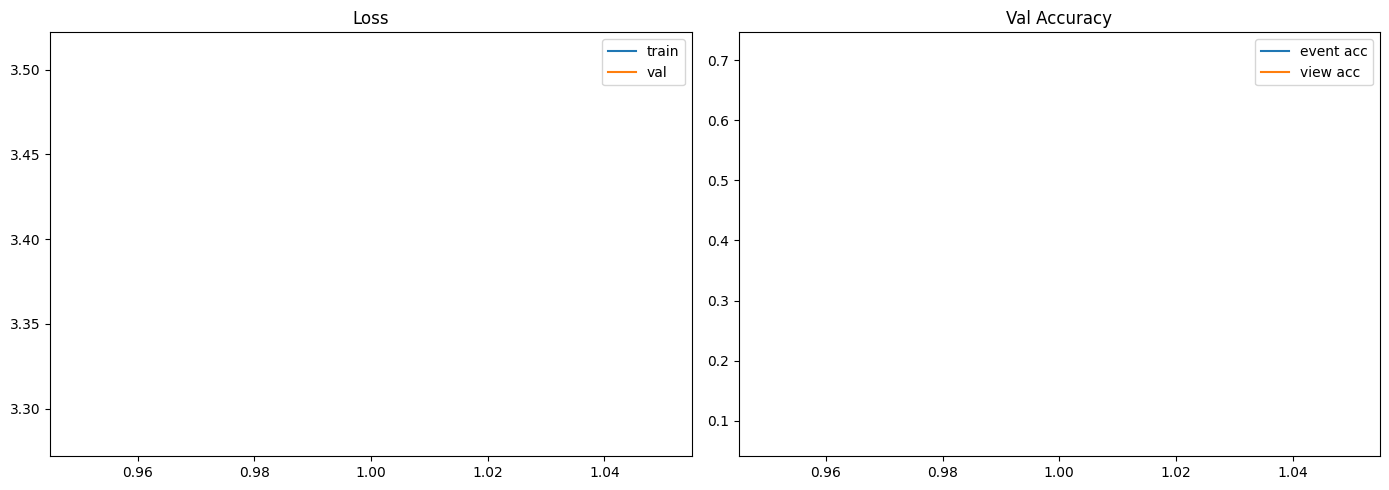

In [13]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history['train_loss'], label='train')
axes[0].plot(epochs, history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(epochs, history['val_event_acc'], label='event acc')
axes[1].plot(epochs, history['val_view_acc'],  label='view acc')
axes[1].set_title('Val Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_training_curves.png', dpi=120)
plt.show()

Error loading image: C:\Users\Yannick\data\soccer\EventClasses\redc\red cards 0832.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\EventClasses\\redc\\red cards 0832.jpg'
Error loading image: C:\Users\Yannick\data\soccer\ViewClasses\MediumView\sprt 068316.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\ViewClasses\\MediumView\\sprt 068316.jpg'
Error loading image: C:\Users\Yannick\data\soccer\ViewClasses\longView\sprt 100179.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\ViewClasses\\longView\\sprt 100179.jpg'
Error loading image: C:\Users\Yannick\data\soccer\ViewClasses\ShotView\sprt 039584.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer\\ViewClasses\\ShotView\\sprt 039584.jpg'
Error loading image: C:\Users\Yannick\data\soccer\EventClasses\yellowcard\Top 20 Famous Red Cards In Football 01071.jpg | [Errno 2] No such file or directory: 'C:\\Users\\Yannick\\data\\soccer

c:\Users\issd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\issd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\issd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

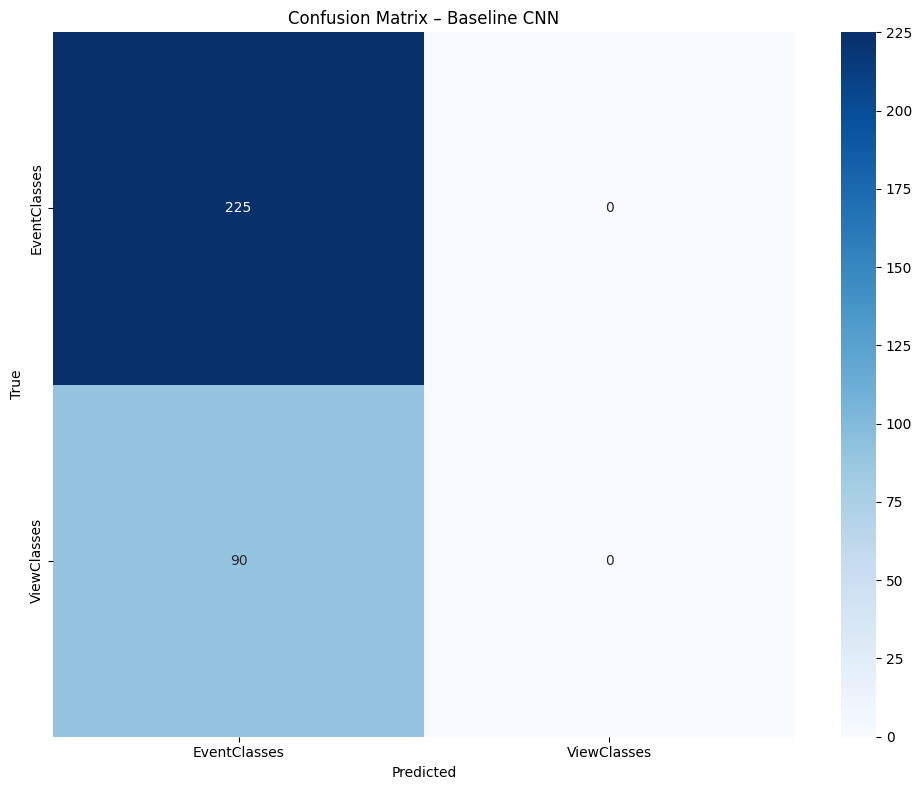

In [14]:
model.eval()
all_et, all_ep = [], []
with torch.no_grad():
    for imgs, ev, vw in test_loader:
        e_out, _ = model(imgs.to(DEVICE))
        all_et.extend(ev.numpy())
        all_ep.extend(e_out.argmax(1).cpu().numpy())

event_classes = sorted(df['event_label'].unique())
print(classification_report(all_et, all_ep, target_names=event_classes))

cm = confusion_matrix(all_et, all_ep)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=event_classes, yticklabels=event_classes)
plt.title('Confusion Matrix – Baseline CNN')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_confusion_matrix.png', dpi=120)
plt.show()

## Summary
This baseline gives a lower-bound reference.  
Identify which classes are hardest before proceeding to transfer learning.

➡️ Continue with **`03_transfer_learning.ipynb`**